In [1]:
import numpy as np
import tensorflow as tf
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization, Input
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 68s 0us/step


In [3]:
x_train.shape

(50000, 32, 32, 3)

In [11]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

Create AlexNet Architecture

In [8]:
model = Sequential()

model.add(Input(shape=(32,32,3)))
model.add(Conv2D(filters=128, kernel_size=(5,5), strides=(1,1), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(3,3)))
model.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1),activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=(1,1), strides=(1,1), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=(1,1), strides=(1,1),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))



In [12]:
model.summary

<bound method Model.summary of <Sequential name=sequential_4, built=True>>

In [9]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [10]:
history=model.fit(x_train, y_train, epochs=30, validation_data=(x_test, y_test))

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.4193 - loss: 1.6146 - val_accuracy: 0.4687 - val_loss: 1.4890
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5577 - loss: 1.2740 - val_accuracy: 0.4098 - val_loss: 2.0904
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6249 - loss: 1.1014 - val_accuracy: 0.5593 - val_loss: 1.3051
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6683 - loss: 0.9895 - val_accuracy: 0.6263 - val_loss: 1.0473
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7020 - loss: 0.8920 - val_accuracy: 0.6434 - val_loss: 1.0592
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7343 - loss: 0.8053 - val_accuracy: 0.5998 - val_loss: 1.1471
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.7596 - loss: 0.7227 - val_accuracy: 0.7028 - val_loss: 0.8786
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.7834 - loss: 

Text(0.5, 1.0, 'horse')

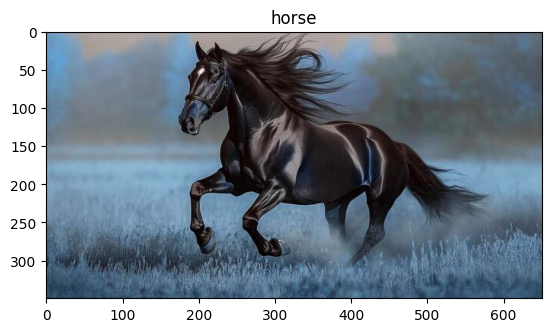

In [13]:
import cv2
img = cv2.imread('/content/horse.jpeg')
plt.imshow(img)
img = cv2.resize(img, (32,32))
img = np.expand_dims(img, axis=0)
result = model.predict(img, verbose = False)
plt.title(labels[result[0].argmax()])